In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import seaborn as sns

color_pal = sns.color_palette()


In [93]:
# Load raw dataset
df = pd.read_csv("dataset.csv")

# Select relevant columns safely
df = df[['Date', 'Total Sales']].copy()

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y', errors='coerce')

# Drop invalid dates or missing rows
df = df.dropna(subset=['Date', 'Total Sales'])

# Sort chronologically
df = df.sort_values('Date')

# Clean Total Sales values
df['Total Sales'] = (
    df['Total Sales']
    .astype(str)
    .str.replace('₦', '')
    .str.replace(',', '')
    .str.strip()
    .astype(float)
)

# Convert sales to billions
df['Sales_Billions'] = df['Total Sales'] / 1e9

# Set index for time series operations
df = df.set_index('Date')

print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2021-01-01 to 2025-12-01
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total Sales     60 non-null     float64
 1   Sales_Billions  60 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB
None


C:\Users\zeid9\AppData\Local\Temp\ipykernel_23260\2806804029.py:2: DtypeWarning: Columns (0,2,3,4,5,6,7,8,9,10,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,Total Sales,Sales_Billions
Date,,
2021-01-01,2.723737e+09,2.723737
2021-02-01,3.172727e+09,3.172727
2021-03-01,3.717273e+09,3.717273
2021-04-01,4.128183e+09,4.128183
2021-05-01,4.624951e+09,4.624951


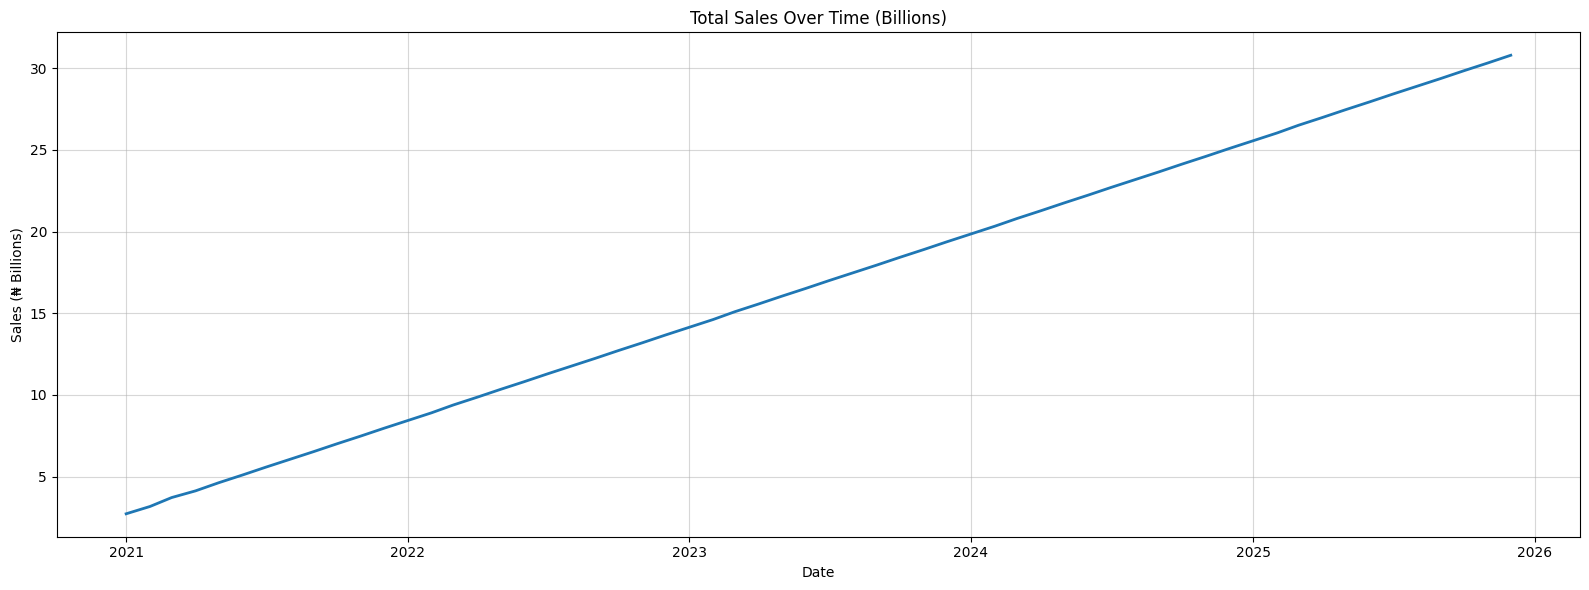

In [94]:
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['Sales_Billions'], linewidth=2)

plt.title("Total Sales Over Time (Billions)")
plt.ylabel("Sales (₦ Billions)")
plt.xlabel("Date")

plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


In [95]:
print("Dataset Overview:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of months: {len(df)}")
print(f"Total Sales range: ₦{df['Total Sales'].min():,.2f} to ₦{df['Total Sales'].max():,.2f}")


Dataset Overview:
Date range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 60
Total Sales range: ₦2,723,737,272.00 to ₦30,793,303,337.00


In [96]:
# Plot
def plot(df, col):
    plt.figure(figsize=(16, 6))
    plt.plot(df.index, df[col], linewidth=2)
    plt.title(f"{col} Over Time")
    plt.ylabel(col)
    plt.xlabel("Date")
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

## Calculate MoM Growth Rate

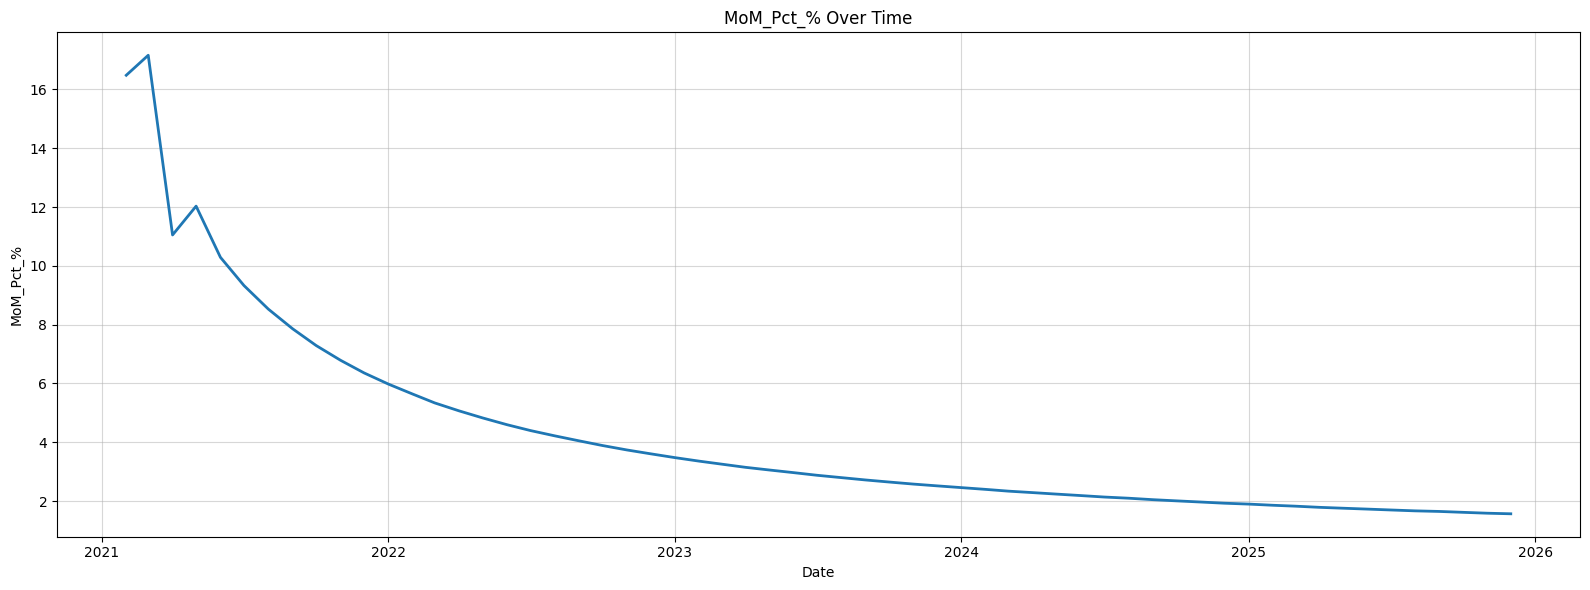

In [97]:
# Month-over-Month Growth Rate
df["MoM_Pct_%"] = (df["Total Sales"].pct_change() * 100).round(2)
plot(df, "MoM_Pct_%")


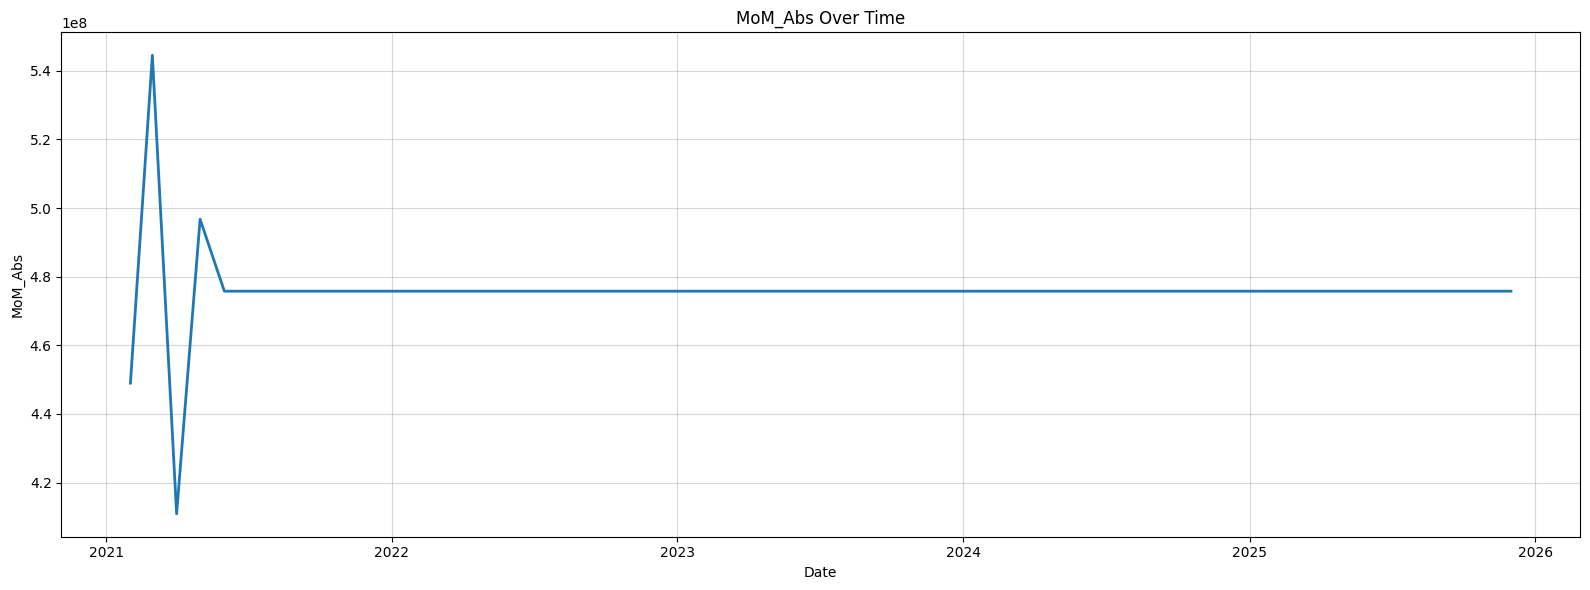

In [98]:
df["MoM_Abs"] = df["Total Sales"].diff()
# Plot MoM Absolute Growth
plot(df, "MoM_Abs")


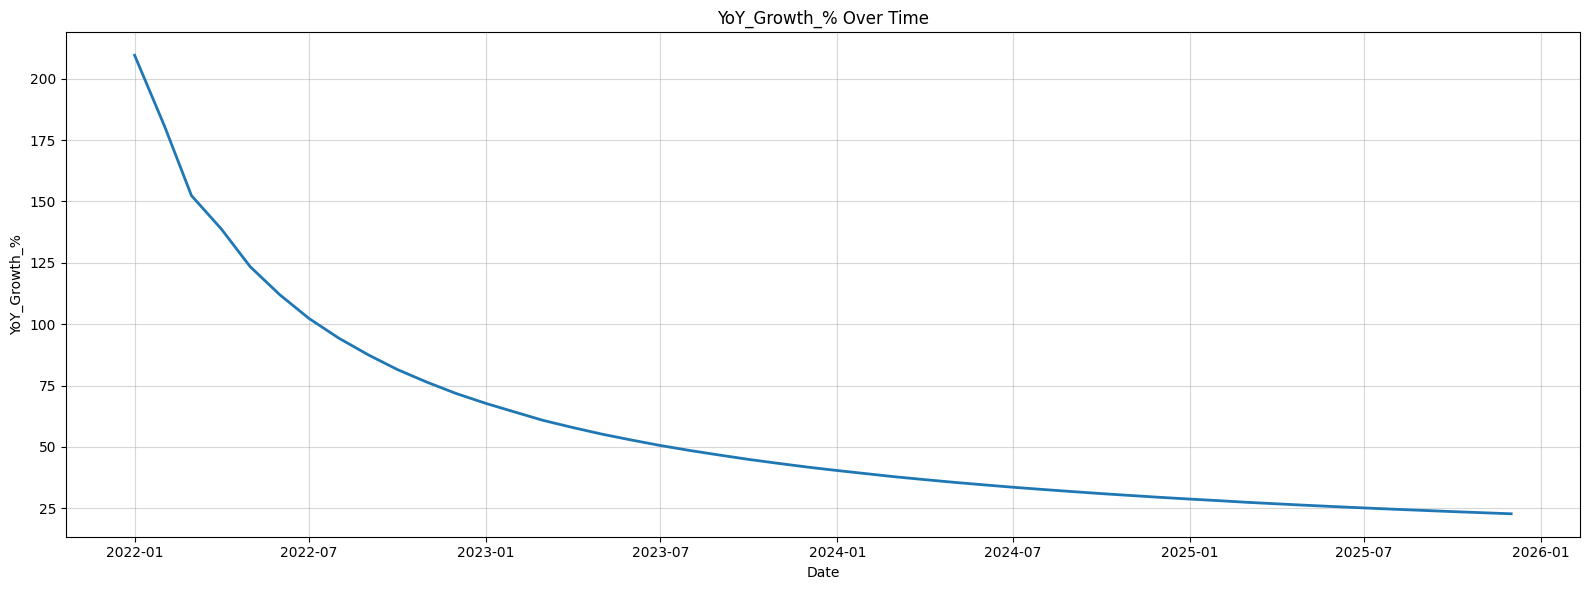

In [99]:
# Year-over-Year Growth Rate`
df["YoY_Growth_%"] = (df["Total Sales"].pct_change(12) * 100).round(2)
# Plot YoY Growth Rate
plot(df, "YoY_Growth_%")


In [100]:
df.head(10)

,Total Sales,Sales_Billions,MoM_Pct_%,MoM_Abs,YoY_Growth_%
Date,,,,,
2021-01-01,2.723737e+09,2.723737,NaN,NaN,NaN
2021-02-01,3.172727e+09,3.172727,16.48,448989900.0,NaN
2021-03-01,3.717273e+09,3.717273,17.16,544545490.0,NaN
2021-04-01,4.128183e+09,4.128183,11.05,410910220.0,NaN
2021-05-01,4.624951e+09,4.624951,12.03,496767695.0,NaN
2021-06-01,5.100739e+09,5.100739,10.29,475788232.0,NaN
2021-07-01,5.576527e+09,5.576527,9.33,475788232.0,NaN
2021-08-01,6.052315e+09,6.052315,8.53,475788232.0,NaN
2021-09-01,6.528104e+09,6.528104,7.86,475788232.0,NaN


# Split Train/Test

In [101]:
test_size = 12  # last 12 months for testing

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]
print(f"Training data from {train.index.min()} to {train.index.max()}")
print(f"Testing data from {test.index.min()} to {test.index.max()}")

Training data from 2021-01-01 00:00:00 to 2024-12-01 00:00:00
Testing data from 2025-01-01 00:00:00 to 2025-12-01 00:00:00


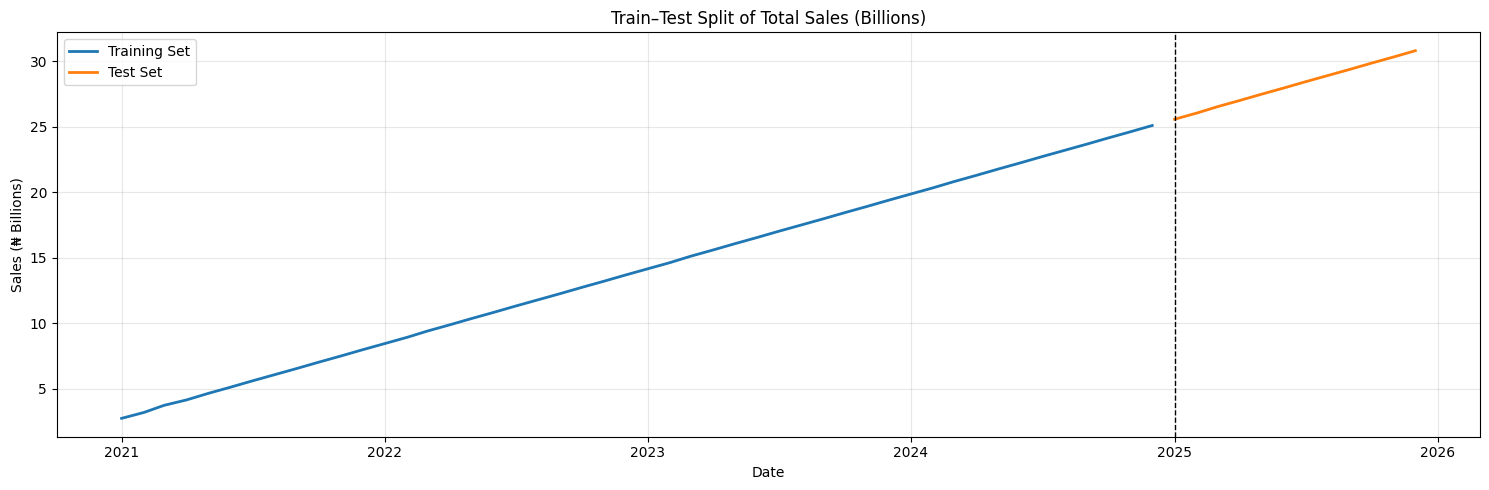

In [102]:
# Plot the split
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train.index, train['Sales_Billions'], label='Training Set', linewidth=2)
ax.plot(test.index, test['Sales_Billions'], label='Test Set', linewidth=2)

# Add split marker automatically
split_point = test.index.min()
ax.axvline(split_point, color='black', linestyle='--', linewidth=1)


# Titles and labels
ax.set_title('Train–Test Split of Total Sales (Billions)')
ax.set_ylabel('Sales (₦ Billions)')
ax.set_xlabel('Date')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# Holt’s Linear Trend Model

In [103]:
model = ExponentialSmoothing(
    train['Total Sales'],
    trend='add',
    seasonal=None
).fit()


c:\Users\zeid9\Documents\forecasting-sale\holt\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [104]:
test_pred = model.forecast(test_size)

# Combine for comparison
results = pd.DataFrame({
    "Actual": test['Total Sales'],
    "Predicted": test_pred
})
results.head()

,Actual,Predicted
2025-01-01,2.555963e+10,2.555963e+10
2025-02-01,2.603542e+10,2.603542e+10
2025-03-01,2.651121e+10,2.651121e+10
2025-04-01,2.698700e+10,2.698700e+10
2025-05-01,2.746279e+10,2.746279e+10


In [105]:
mae = mean_absolute_error(results['Actual'], results['Predicted'])
rmse = np.sqrt(mean_squared_error(results['Actual'], results['Predicted']))

mae, rmse


(9.330879847208658, np.float64(9.349572614709501))

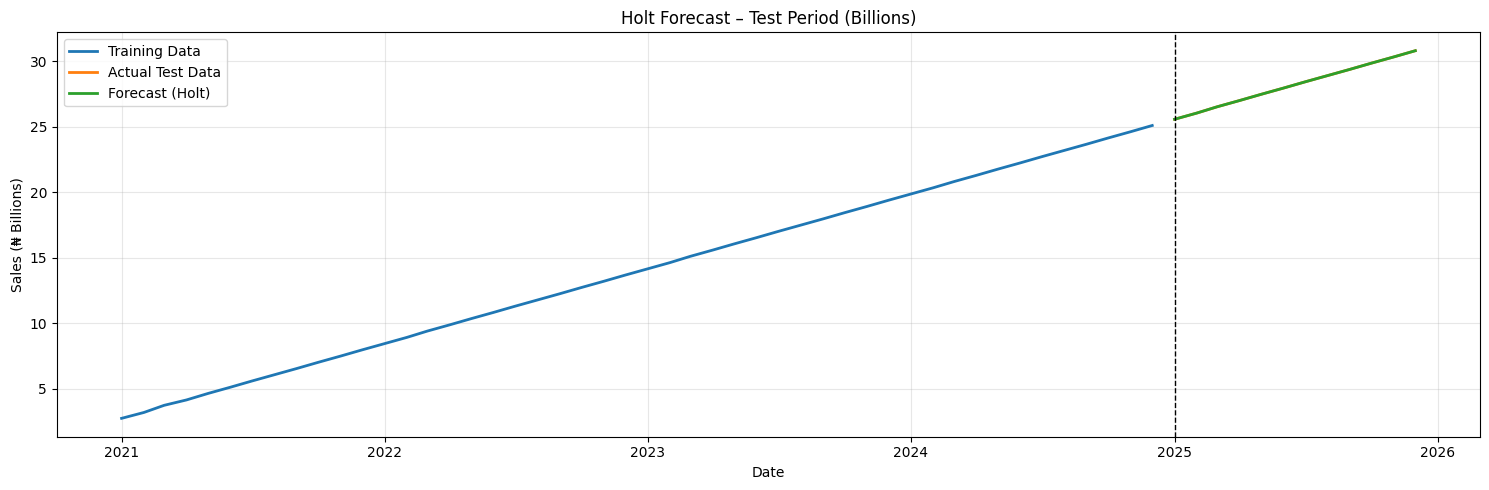

In [106]:
# Forecast Plot (Styled like the Train–Test Split)

fig, ax = plt.subplots(figsize=(15, 5))

# Plot training data
ax.plot(train.index, train['Sales_Billions'], 
        label='Training Data', linewidth=2)

# Plot actual test data
ax.plot(test.index, test['Sales_Billions'], 
        label='Actual Test Data', linewidth=2)

# Plot forecast
ax.plot(test_pred.index, test_pred / 1e9, 
        label='Forecast (Holt)', linewidth=2)

# Vertical line marking start of test set
split_point = test.index.min()
ax.axvline(split_point, color='black', linestyle='--', linewidth=1)

# Titles & labels
ax.set_title("Holt Forecast – Test Period (Billions)")
ax.set_ylabel("Sales (₦ Billions)")
ax.set_xlabel("Date")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# Run the model with the full dataset

In [107]:
model = ExponentialSmoothing(
    df['Total Sales'],
    trend='add',
    seasonal=None
).fit()


c:\Users\zeid9\Documents\forecasting-sale\holt\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# Forecast Into the Future (Business Use Case)

In [108]:
future_months = 12
future_forecast = model.forecast(future_months)

In [109]:
"""get the last date in the dataset to determin when are forecast starting from,
and setting the time range for forecasting to 1 years
"""
future_df = pd.DataFrame({
    "Date": pd.date_range(
        start=df.index[-1] + pd.offsets.MonthBegin(),
        periods=future_months,
        freq='MS'
    ),
    "Forecast": future_forecast
}).set_index("Date")

In [112]:
# combine historical and forecast data for reporting
report_data = pd.concat([df, future_df], axis=0)
report_data.head(15)

,Total Sales,Sales_Billions,MoM_Pct_%,MoM_Abs,YoY_Growth_%,Forecast
Date,,,,,,
2021-01-01,2.723737e+09,2.723737,NaN,NaN,NaN,NaN
2021-02-01,3.172727e+09,3.172727,16.48,448989900.0,NaN,NaN
2021-03-01,3.717273e+09,3.717273,17.16,544545490.0,NaN,NaN
2021-04-01,4.128183e+09,4.128183,11.05,410910220.0,NaN,NaN
2021-05-01,4.624951e+09,4.624951,12.03,496767695.0,NaN,NaN
2021-06-01,5.100739e+09,5.100739,10.29,475788232.0,NaN,NaN
2021-07-01,5.576527e+09,5.576527,9.33,475788232.0,NaN,NaN
2021-08-01,6.052315e+09,6.052315,8.53,475788232.0,NaN,NaN
2021-09-01,6.528104e+09,6.528104,7.86,475788232.0,NaN,NaN


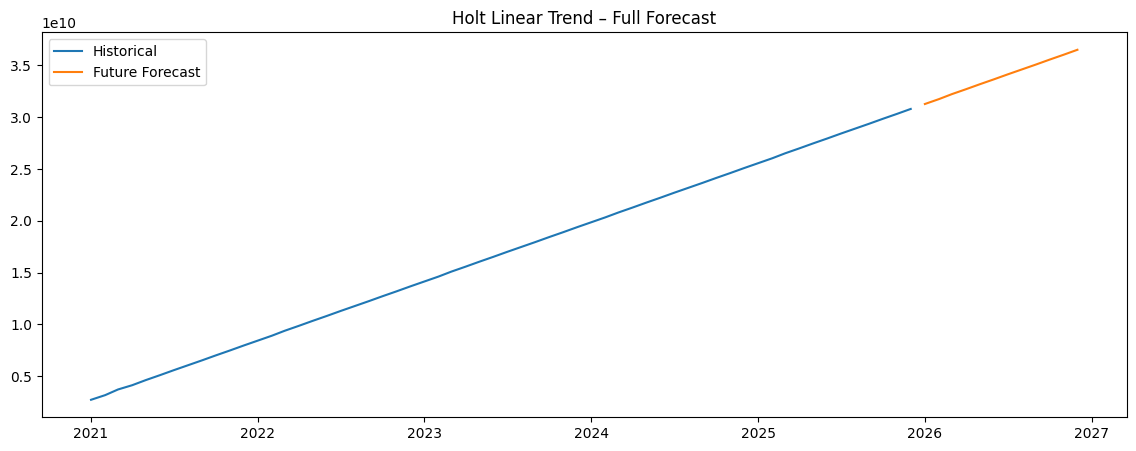

In [111]:
plt.figure(figsize=(14,5))
plt.plot(df['Total Sales'], label="Historical")
plt.plot(future_df['Forecast'], label="Future Forecast")
plt.title("Holt Linear Trend – Full Forecast")
plt.legend()
plt.show()
